In [1]:
#import libraries
import time
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objs as go
import matplotlib.pyplot as plt
import seaborn as sns
import csv
import nltk

from sklearn.linear_model import LinearRegression, Lasso, LogisticRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, LabelEncoder, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.feature_selection import SequentialFeatureSelector, SelectFromModel
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score, precision_score, recall_score, confusion_matrix, classification_report, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.svm import SVC, SVR
from sklearn.dummy import DummyClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.naive_bayes import GaussianNB
from sklearn import set_config
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.naive_bayes import GaussianNB

set_config(display="diagram")

In [2]:
#Import data
#d1 = a set of predictions that assume all and only female passengers survive, as an example of what a submission file should look like.
#d2 = train data passengers full data
#d3 = test data passengers X_features
d1 = pd.read_csv('Data/gender_submission.csv')
d2 = pd.read_csv('Data/titanic_train.csv')
d3 = pd.read_csv('Data/titanic_test.csv')

In [3]:
#Data Dictionary
#Survival: 0 = No, 1 = Yes
#Pclass(Ticket class) (1 = upper, 2 = middle, 3 = lower)
#SibSp = # of siblings/spouses aboard
#ParCh = # of parents / children aboard
#Ticket = ticket number
#Fare = passenger fare
#Cabin = cabin number
#Embarked = port of embarkation

In [4]:
d1.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


In [5]:
d2.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
d2.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [7]:
d3.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [8]:
d1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   PassengerId  418 non-null    int64
 1   Survived     418 non-null    int64
dtypes: int64(2)
memory usage: 6.7 KB


In [9]:
d2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [10]:
d3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.0+ KB


In [11]:
d1.isnull().sum()

PassengerId    0
Survived       0
dtype: int64

In [12]:
d2.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [13]:
d3.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [14]:
d2.shape

(891, 12)

In [15]:
#d2 = d2.drop(columns = 'Cabin', axis = 1)
#d3 = d3.drop(columns = 'Cabin', axis = 1)

In [16]:
d2['Cabin'] = d2['Cabin'].fillna('U')
d3['Cabin'] = d3['Cabin'].fillna('U')
d2['Cabin_Cat'] = d2['Cabin'].apply(lambda x: 0 if x in ['U'] else 1)
d3['Cabin_Cat'] = d3['Cabin'].apply(lambda x: 0 if x in ['U'] else 1)

In [17]:
d2['Age'].fillna(d2['Age'].mean(), inplace = True)
d3['Age'].fillna(d3['Age'].mean(), inplace = True)

In [18]:
d3['Fare'].fillna(d3['Fare'].mean(), inplace = True)

In [19]:
d2.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       2
Cabin_Cat      0
dtype: int64

In [20]:
d2['Embarked'].fillna(d2['Embarked'].mode()[0], inplace = True)

In [21]:
d2.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
Cabin_Cat      0
dtype: int64

In [22]:
d2.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Cabin_Cat
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208,0.228956
std,257.353842,0.486592,0.836071,13.002015,1.102743,0.806057,49.693429,0.420397
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400,0.000000
50%,446.000000,0.000000,3.000000,29.699118,0.000000,0.000000,14.454200,0.000000
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000,0.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200,1.000000


In [23]:
d2['Famsi'] = d2['SibSp'] + d2['Parch'] + 1
d3['Famsi'] = d3['SibSp'] + d3['Parch'] + 1

In [24]:
d2.groupby(['Sex'], as_index = False)['Survived'].mean()

,Sex,Survived
0,female,0.742038
1,male,0.188908


In [25]:
d2['Age_Group'] = (d2['Age']//18)*18
d3['Age_Group'] = (d3['Age']//18)*18
#age_grouped2 = d2.groupby('Age_Group').size()
#age_grouped3 = d3.groupby('Age_Group').size()
d2.groupby(['Age_Group'], as_index = False)['Survived'].mean()

,Age_Group,Survived
0,0.0,0.539823
1,18.0,0.352941
2,36.0,0.401198
3,54.0,0.312500
4,72.0,0.500000


In [26]:
d2['Fare_Group'] = (d2['Fare']//25)*25
d3['Fare_Group'] = (d3['Fare']//25)*25
#age_grouped2 = d2.groupby('Age_Group').size()
#age_grouped3 = d3.groupby('Age_Group').size()
d2.groupby(['Fare_Group'], as_index = False)['Survived'].mean()

,Fare_Group,Survived
0,0.0,0.287253
1,25.0,0.421965
2,50.0,0.546875
3,75.0,0.795455
4,100.0,0.733333
5,125.0,0.888889
6,150.0,0.666667
7,200.0,0.600000
8,225.0,0.666667
9,250.0,0.666667


In [27]:
d2[d2['Age_Group'] == 70]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Cabin_Cat,Famsi,Age_Group,Fare_Group


In [28]:
d2.groupby(['Pclass'], as_index = False)['Survived'].mean()

,Pclass,Survived
0,1,0.629630
1,2,0.472826
2,3,0.242363


In [29]:
d2.groupby(['SibSp'], as_index = False)['Survived'].mean()

,SibSp,Survived
0,0,0.345395
1,1,0.535885
2,2,0.464286
3,3,0.250000
4,4,0.166667
5,5,0.000000
6,8,0.000000


In [30]:
d2.groupby(['Parch'], as_index = False)['Survived'].mean()

,Parch,Survived
0,0,0.343658
1,1,0.550847
2,2,0.500000
3,3,0.600000
4,4,0.000000
5,5,0.200000
6,6,0.000000


In [31]:
d2.groupby(['Famsi'], as_index = False)['Survived'].mean()

,Famsi,Survived
0,1,0.303538
1,2,0.552795
2,3,0.578431
3,4,0.724138
4,5,0.200000
5,6,0.136364
6,7,0.333333
7,8,0.000000
8,11,0.000000


In [32]:
family_map = {1: 'Alone', 2: 'Small', 3: 'Small', 4: 'Small', 5:'Medium', 6: 'Medium', 7: 'Large', 8: 'Large', 11: 'Large'}
d2['Famsi_Grouped'] = d2['Famsi'].map(family_map)
d3['Famsi_Grouped'] = d3['Famsi'].map(family_map)

In [33]:
d2.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Cabin_Cat,Famsi,Age_Group,Fare_Group,Famsi_Grouped
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,U,S,0,2,18.0,0.0,Small
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1,2,36.0,50.0,Small
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,U,S,0,1,18.0,0.0,Alone
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1,2,18.0,50.0,Small
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,U,S,0,1,18.0,0.0,Alone


In [34]:
d2.groupby(['Famsi_Grouped'], as_index = False)['Survived'].mean()

,Famsi_Grouped,Survived
0,Alone,0.303538
1,Large,0.160000
2,Medium,0.162162
3,Small,0.578767


In [35]:
d2.groupby(['Embarked'], as_index = False)['Survived'].mean()

,Embarked,Survived
0,C,0.553571
1,Q,0.389610
2,S,0.339009


In [36]:
d2['Ticket_Number'] = d2['Ticket'].apply(lambda x: pd.Series({'Ticket': x.split()[-1]}))
d3['Ticket_Number'] = d3['Ticket'].apply(lambda x: pd.Series({'Ticket': x.split()[-1]}))

In [37]:
d2.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Cabin_Cat,Famsi,Age_Group,Fare_Group,Famsi_Grouped,Ticket_Number
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,U,S,0,2,18.0,0.0,Small,21171
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1,2,36.0,50.0,Small,17599
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,U,S,0,1,18.0,0.0,Alone,3101282
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1,2,18.0,50.0,Small,113803
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,U,S,0,1,18.0,0.0,Alone,373450


In [38]:
d2.groupby(['Cabin_Cat'], as_index = False)['Survived'].agg(['count','mean'])

,count,mean
Cabin_Cat,,
0,687,0.299854
1,204,0.666667


In [39]:
d2.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Cabin_Cat,Famsi,Age_Group,Fare_Group,Famsi_Grouped,Ticket_Number
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,U,S,0,2,18.0,0.0,Small,21171
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1,2,36.0,50.0,Small,17599
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,U,S,0,1,18.0,0.0,Alone,3101282
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1,2,18.0,50.0,Small,113803
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,U,S,0,1,18.0,0.0,Alone,373450


In [40]:
d2.shape

(891, 18)

In [41]:
d3.shape

(418, 17)

In [42]:
d2.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin            0
Embarked         0
Cabin_Cat        0
Famsi            0
Age_Group        0
Fare_Group       0
Famsi_Grouped    0
Ticket_Number    0
dtype: int64

In [43]:
OHE = OneHotEncoder(sparse_output = False)
ODE = OrdinalEncoder
SI = SimpleImputer(strategy= 'most_frequent')

In [44]:
ohe_cols = ['Famsi_Grouped']
ode_cols = ['Sex','Embarked']

In [45]:
d2.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Cabin_Cat,Famsi,Age_Group,Fare_Group,Famsi_Grouped,Ticket_Number
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,U,S,0,2,18.0,0.0,Small,21171
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1,2,36.0,50.0,Small,17599
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,U,S,0,1,18.0,0.0,Alone,3101282
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1,2,18.0,50.0,Small,113803
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,U,S,0,1,18.0,0.0,Alone,373450


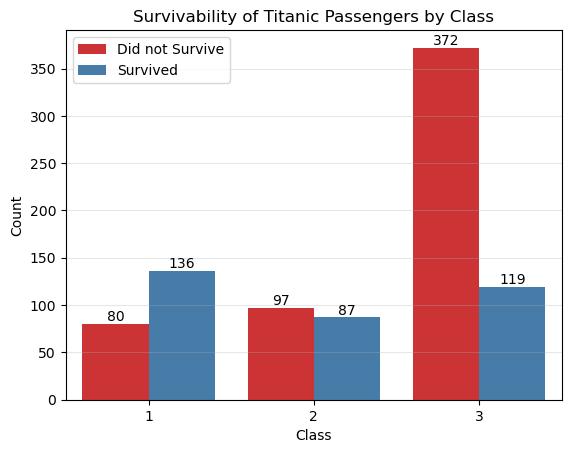

In [46]:
plt1 = sns.countplot(data=d2, x='Pclass', hue = 'Survived', palette='Set1')

for container in plt1.containers:
    plt1.bar_label(container, fmt='%d')

plt.title('Survivability of Titanic Passengers by Class')
plt.xlabel('Class')
plt.ylabel('Count')
plt.grid(axis='y', alpha=.3)
plt.legend(labels=['Did not Survive', 'Survived'])
plt.savefig("Images/Titanic/Survivability_by_Class.png")
plt.show()

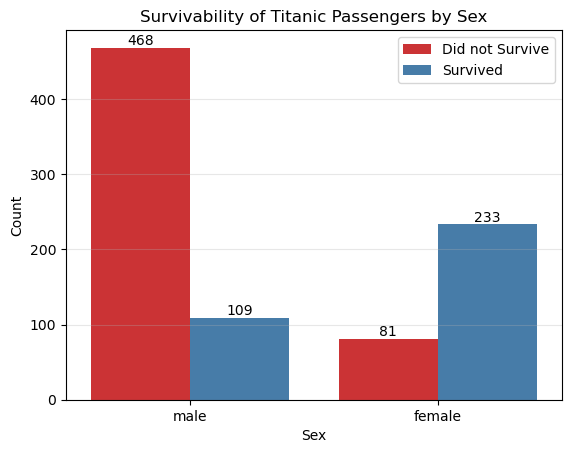

In [47]:
plt2 = sns.countplot(data=d2, x='Sex', hue = 'Survived', palette='Set1')

for container in plt2.containers:
    plt2.bar_label(container, fmt='%d')

plt.title('Survivability of Titanic Passengers by Sex')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.legend(labels=['Did not Survive', 'Survived'])
plt.grid(axis='y', alpha=.3)
plt.savefig("Images/Titanic/Survivability_by_Sex.png")
plt.show()

In [48]:
d2.replace({'Sex':{'male':0,'female':1}, 'Embarked':{'S':'Southampton','C':'Cherbourg','Q':'Queenstown'}, 'Age_Group':{0.0:'0-18', 18.0:'18-36', 36.0:'36-54', 54.0:'54-72',72.0:'72-90'}}, inplace = True)
d3.replace({'Sex':{'male':0,'female':1}, 'Embarked':{'S':0,'C':1,'Q':2}}, inplace = True)

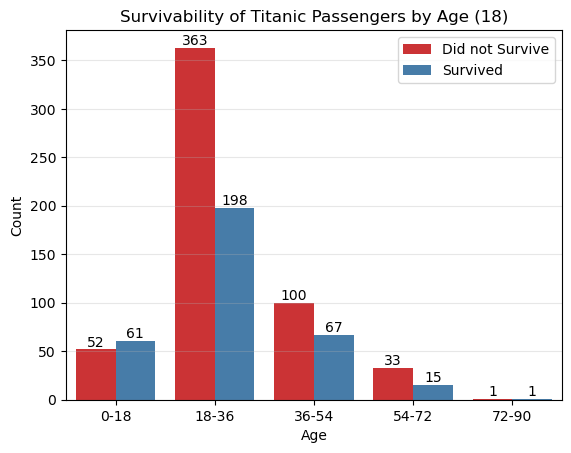

In [49]:
custom = ['0-18', '18-36', '36-54', '54-72', '72-90']
plt3 = sns.countplot(data=d2, x='Age_Group', hue = 'Survived', palette='Set1', order = custom)

for container in plt3.containers:
    plt3.bar_label(container, fmt='%d')

plt.title('Survivability of Titanic Passengers by Age (18)')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend(labels=['Did not Survive', 'Survived'])
plt.grid(axis='y', alpha=.3)
plt.savefig("Images/Titanic/Survivability_by_Age_18.png")
plt.show()

In [50]:
d2['Age_Group'] = (d2['Age']//10)*10
d3['Age_Group'] = (d3['Age']//10)*10
#age_grouped2 = d2.groupby('Age_Group').size()
#age_grouped3 = d3.groupby('Age_Group').size()
d2.groupby(['Age_Group'], as_index = False)['Survived'].mean()

,Age_Group,Survived
0,0.0,0.612903
1,10.0,0.401961
2,20.0,0.324937
3,30.0,0.437126
4,40.0,0.382022
5,50.0,0.416667
6,60.0,0.315789
7,70.0,0.000000
8,80.0,1.000000


In [51]:
d2.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Cabin_Cat,Famsi,Age_Group,Fare_Group,Famsi_Grouped,Ticket_Number
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,U,Southampton,0,2,20.0,0.0,Small,21171
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,Cherbourg,1,2,30.0,50.0,Small,17599
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,U,Southampton,0,1,20.0,0.0,Alone,3101282
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,Southampton,1,2,30.0,50.0,Small,113803
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,U,Southampton,0,1,30.0,0.0,Alone,373450


In [52]:
d2.replace({'Age_Group':{0.0:'0-10', 10.0:'10-20', 20.0:'20-30', 30.0:'30-40',40.0:'40-50',50.0:'50-60',60.0:'60-70',70.0:'70-80',80.0:'80-90',90.0:'90-100'}}, inplace = True)

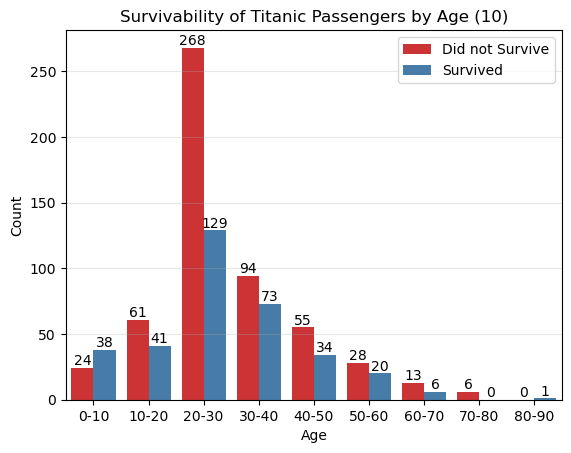

In [53]:
custom = ['0-10', '10-20','20-30', '30-40','40-50', '50-60', '60-70', '70-80', '80-90']
plt3 = sns.countplot(data=d2, x='Age_Group', hue = 'Survived', palette='Set1', order = custom)

for container in plt3.containers:
    plt3.bar_label(container, fmt='%d')

plt.title('Survivability of Titanic Passengers by Age (10)')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend(labels=['Did not Survive', 'Survived'])
plt.grid(axis='y', alpha=.3)
plt.savefig("Images/Titanic/Survivability_by_Age_10.png")
plt.show()

In [54]:
d2.replace({'Age_Group':{'0-10':0.0,'10-20':10.0,'20-30':20.0,'30-40':30.0,'40-50':40.0,'50-60':50.0,'60-70':60.0,'70-80':70.0,'80-90':80.0}}, inplace = True)

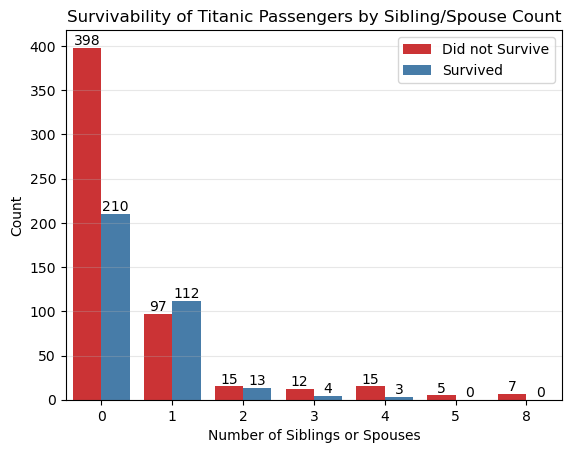

In [55]:
plt4 = sns.countplot(data=d2, x='SibSp', hue = 'Survived', palette='Set1')

for container in plt4.containers:
    plt4.bar_label(container, fmt='%d')

plt.title('Survivability of Titanic Passengers by Sibling/Spouse Count')
plt.xlabel('Number of Siblings or Spouses')
plt.ylabel('Count')
plt.legend(labels=['Did not Survive', 'Survived'])
plt.grid(axis='y', alpha=.3)
plt.savefig("Images/Titanic/Survivability_by_SiblingSpouse.png")
plt.show()

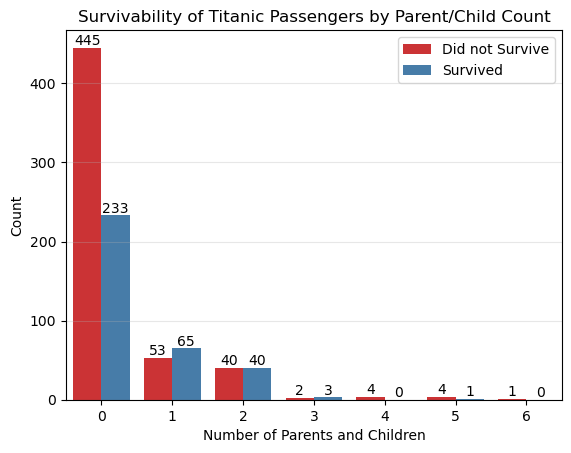

In [56]:
plt5 = sns.countplot(data=d2, x='Parch', hue = 'Survived', palette='Set1')

for container in plt5.containers:
    plt5.bar_label(container, fmt='%d')

plt.title('Survivability of Titanic Passengers by Parent/Child Count')
plt.xlabel('Number of Parents and Children')
plt.ylabel('Count')
plt.legend(labels=['Did not Survive', 'Survived'])
plt.grid(axis='y', alpha=.3)
plt.savefig("Images/Titanic/Survivability_by_ParentChild.png")
plt.show()

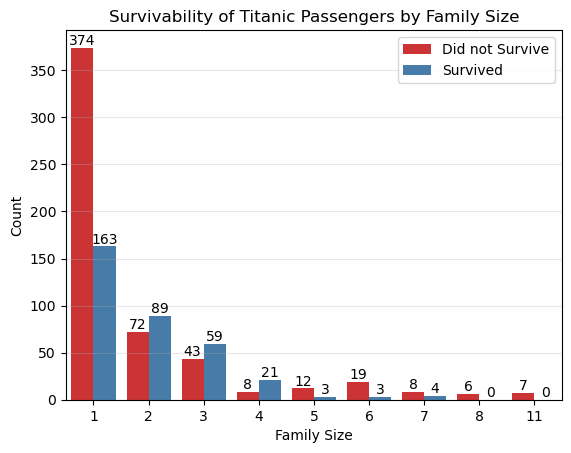

In [57]:
plt6 = sns.countplot(data=d2, x='Famsi', hue = 'Survived', palette='Set1')

for container in plt6.containers:
    plt6.bar_label(container, fmt='%d')

plt.title('Survivability of Titanic Passengers by Family Size')
plt.xlabel('Family Size')
plt.ylabel('Count')
plt.legend(labels=['Did not Survive', 'Survived'])
plt.grid(axis='y', alpha=.3)
plt.savefig("Images/Titanic/Survivability_by_Famsi.png")
plt.show()

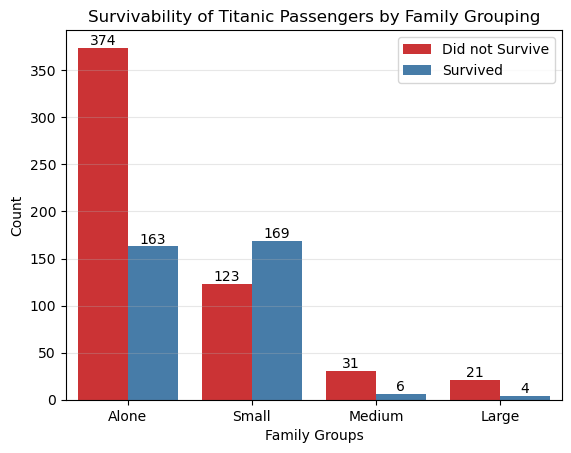

In [58]:
custom = ['Alone', 'Small', 'Medium', 'Large']

plt7 = sns.countplot(data=d2, x='Famsi_Grouped', hue = 'Survived', palette='Set1', order = custom)

for container in plt7.containers:
    plt7.bar_label(container, fmt='%d')

plt.title('Survivability of Titanic Passengers by Family Grouping')
plt.xlabel('Family Groups')
plt.ylabel('Count')
plt.legend(labels=['Did not Survive', 'Survived'])
plt.grid(axis='y', alpha=.3)
plt.savefig("Images/Titanic/Survivability_by_Famsi_Grouped.png")
plt.show()

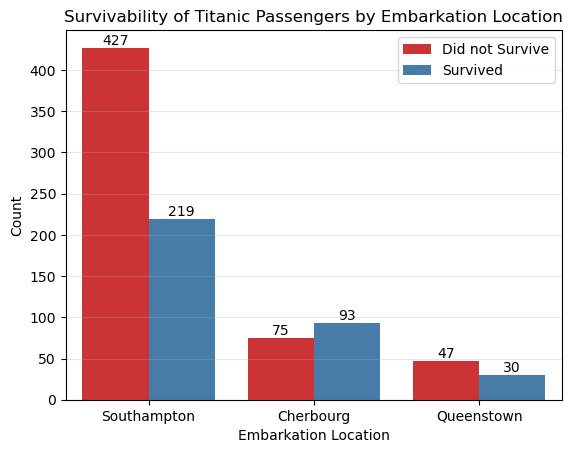

In [59]:
plt8 = sns.countplot(data=d2, x='Embarked', hue = 'Survived', palette='Set1')

for container in plt8.containers:
    plt8.bar_label(container, fmt='%d')

plt.title('Survivability of Titanic Passengers by Embarkation Location')
plt.xlabel('Embarkation Location')
plt.ylabel('Count')
plt.legend(labels=['Did not Survive', 'Survived'])
plt.grid(axis='y', alpha=.3)
plt.savefig("Images/Titanic/Survivability_by_Embarkation.png")
plt.show()

In [60]:
d2.replace({'Embarked':{'Southampton':1,'Cherbourg':2,'Queenstown':3}},inplace = True)
d2.head()
#, 'Fare_Group': {0.0:'0-25', 25.0:'25-50', 50.0:'50-75',75.0:'75-100', 100.0: '100-125', 125.0:'125-150',150.0: '150-175', 200.0: '200-225', 225.0:'225-250', 250.0: '250-275', 500.0: '500-525'}

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Cabin_Cat,Famsi,Age_Group,Fare_Group,Famsi_Grouped,Ticket_Number
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,U,1,0,2,20.0,0.0,Small,21171
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,2,1,2,30.0,50.0,Small,17599
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,U,1,0,1,20.0,0.0,Alone,3101282
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,1,1,2,30.0,50.0,Small,113803
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,U,1,0,1,30.0,0.0,Alone,373450


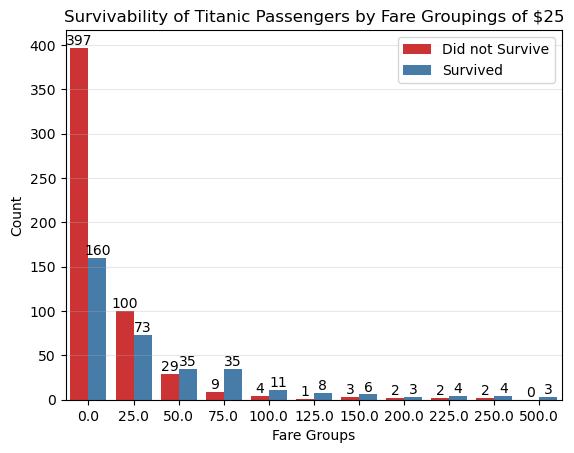

In [61]:
#custom = ['0-25', '25-50', '50-75','75-100','100-125','125-150','150-175','200-225','225-250','250-275','500-525']
plt9 = sns.countplot(data=d2, x='Fare_Group', hue = 'Survived', palette='Set1')

for container in plt9.containers:
    plt9.bar_label(container, fmt='%d')

plt.title('Survivability of Titanic Passengers by Fare Groupings of $25')
plt.xlabel('Fare Groups')
plt.ylabel('Count')
plt.legend(labels=['Did not Survive', 'Survived'])
plt.grid(axis='y', alpha=.3)
plt.savefig("Images/Titanic/Survivability_by_Fare_Grouped.png")
plt.show()

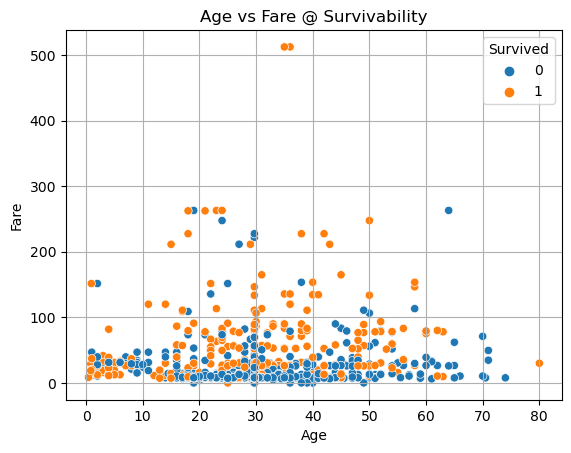

In [62]:
sp1 = sns.scatterplot(data=d2, x='Age', y='Fare', hue = 'Survived')
plt.title("Age vs Fare @ Survivability")
plt.xlabel("Age")
plt.ylabel("Fare")
#plt.legend(labels=['Did not Survive', 'Survived'])
plt.grid(True)
plt.savefig("Images/Titanic/Age_vs_Fare.png")
plt.show()

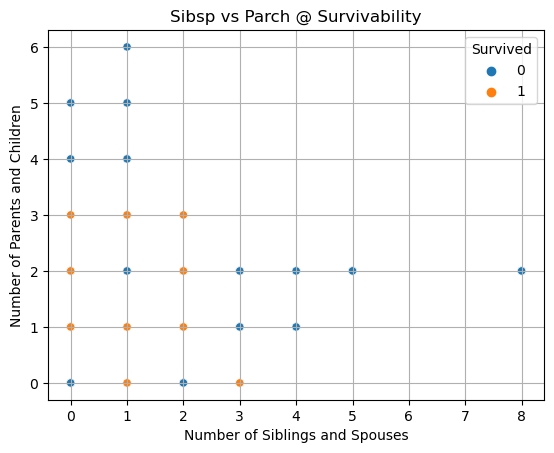

In [63]:
sp2 = sns.scatterplot(data=d2, x='SibSp', y='Parch', hue = 'Survived')
plt.title("Sibsp vs Parch @ Survivability")
plt.xlabel("Number of Siblings and Spouses")
plt.ylabel("Number of Parents and Children")
plt.grid(True)
plt.savefig("Images/Titanic/Sibsp_vs_Parch.png")
plt.show()
#Survival: 0 = No, 1 = Yes

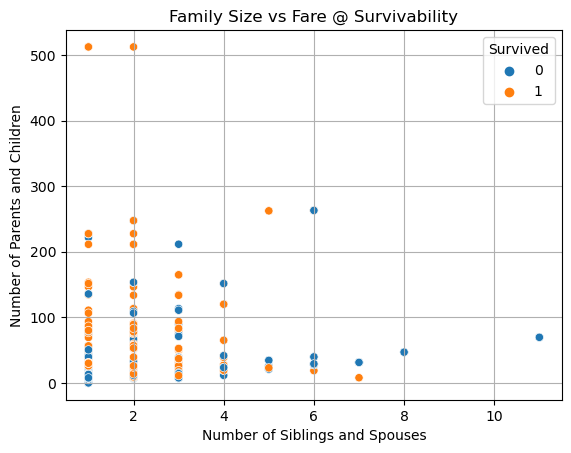

In [64]:
sp3 = sns.scatterplot(data=d2, x='Famsi', y='Fare', hue = 'Survived')
plt.title("Family Size vs Fare @ Survivability")
plt.xlabel("Number of Siblings and Spouses")
plt.ylabel("Number of Parents and Children")
plt.grid(True)
plt.savefig("Images/Titanic/Famsi_v_Fare.png")
plt.show()
#Survival: 0 = No, 1 = Yes

C:\Users\marcu\AppData\Local\Temp\ipykernel_43556\2617575367.py:3: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(d2.corr(), annot=True)


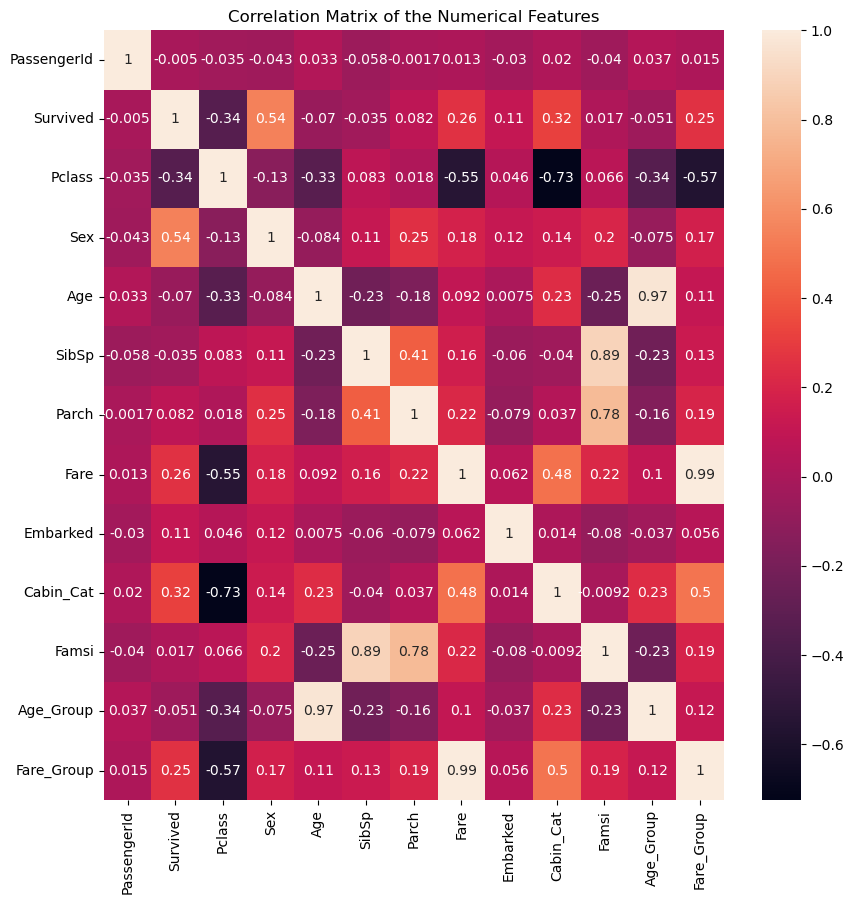

In [65]:
hm1 = d2.corr(numeric_only = True)
plt.figure(figsize=(10, 10))
sns.heatmap(d2.corr(), annot=True)
plt.title('Correlation Matrix of the Numerical Features')
plt.savefig("Images/Titanic/Corr_HM.png")

In [66]:
d2.drop(columns = ['Cabin'])

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Cabin_Cat,Famsi,Age_Group,Fare_Group,Famsi_Grouped,Ticket_Number
0,1,0,3,"Braund, Mr. Owen Harris",0,22.000000,1,0,A/5 21171,7.2500,1,0,2,20.0,0.0,Small,21171
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.000000,1,0,PC 17599,71.2833,2,1,2,30.0,50.0,Small,17599
2,3,1,3,"Heikkinen, Miss. Laina",1,26.000000,0,0,STON/O2. 3101282,7.9250,1,0,1,20.0,0.0,Alone,3101282
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.000000,1,0,113803,53.1000,1,1,2,30.0,50.0,Small,113803
4,5,0,3,"Allen, Mr. William Henry",0,35.000000,0,0,373450,8.0500,1,0,1,30.0,0.0,Alone,373450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",0,27.000000,0,0,211536,13.0000,1,0,1,20.0,0.0,Alone,211536
887,888,1,1,"Graham, Miss. Margaret Edith",1,19.000000,0,0,112053,30.0000,1,1,1,10.0,25.0,Alone,112053
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",1,29.699118,1,2,W./C. 6607,23.4500,1,0,4,20.0,0.0,Small,6607
889,890,1,1,"Behr, Mr. Karl Howell",0,26.000000,0,0,111369,30.0000,2,1,1,20.0,25.0,Alone,111369


In [67]:
y = d2['Survived']
X = d2.drop(columns = ['PassengerId','Survived','Name', 'Ticket', 'Cabin','Ticket_Number', 'Famsi_Grouped'], axis = 1)

In [68]:
#Numerical Features (Age, SibSp, Parch, Fare)
#Categorical Features (Survived, Pclass, Sex, Embarked)
dclean = d2.drop(columns= ['Survived','Name','Ticket','Cabin','Famsi_Grouped'])

In [69]:
scaler = StandardScaler()
#X_scaled = scaler.fit_transform(dclean)
#X_scaled.head()

In [70]:
d2.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Cabin_Cat,Famsi,Age_Group,Fare_Group,Famsi_Grouped,Ticket_Number
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,U,1,0,2,20.0,0.0,Small,21171
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,2,1,2,30.0,50.0,Small,17599
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,U,1,0,1,20.0,0.0,Alone,3101282
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,1,1,2,30.0,50.0,Small,113803
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,U,1,0,1,30.0,0.0,Alone,373450


In [71]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [72]:
ord_pipeline = Pipeline(steps = [
 ('impute', SimpleImputer(strategy='most frequent')),
    ('ord', OrdinalEncoder(handle_unknown = 'use_encoded_value', unknown_value=-1))
])

In [73]:
ohe_pipeline = Pipeline(steps = [
    ('impute', SimpleImputer(strategy = 'most frequent')),
    ('one-hot', OneHotEncoder(handle_unknown = 'ignore',sparse_output = False))
])

In [74]:
col_trans = ColumnTransformer(transformers = [
    ('impute', SI, ['Age']),
    ('ord_pipeline',ord_pipeline,ode_cols),
    ('ohe_pipeline',ohe_pipeline, ohe_cols),
    ('passthrough', 'passthrough', ['Pclass','Age', 'Fare', 'Famsi', 'Cabin_Cat'])],
    remainder = 'drop',
    n_jobs = -1)

In [75]:
lr = LogisticRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)
lr_train_acc = accuracy_score(y_train, lr.predict(X_train))
lr_test_acc = accuracy_score(y_test, lr.predict(X_test))
print(f"LR accuracy (train): {lr_train_acc} seconds")
print(f"LR accuracy (test): {lr_test_acc} seconds")

lr_mse = mean_squared_error(y_test, lr_pred)
lr_r2 = r2_score(y_test, lr_pred)
print(f"LR MSE: {lr_mse}")
print(f"LR R^2 Score {lr_r2}")

lr_precision = precision_score(y_test, lr_pred, average = 'weighted')
lr_recall = recall_score(y_test, lr_pred, average = 'weighted')
print(f"LR Precision Score: {lr_precision}")
print(f"LR Recall Score {lr_recall}")

LR accuracy (train): 0.8061797752808989 seconds
LR accuracy (test): 0.8044692737430168 seconds
LR MSE: 0.19553072625698323
LR R^2 Score 0.1936936936936937
LR Precision Score: 0.8036409018980425
LR Recall Score 0.8044692737430168


C:\Users\marcu\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [76]:
pg = {
    'C':[100,10,1,.1,.01,.001],
    'penalty': ['l1','l2','elasticnet','none'],
    'solver': ['liblinear','saga','lbfgs'],
    'max_iter': [100,200,300],
    'class_weight': [None,'balanced']
    }

In [77]:
lr_GSCV = GridSearchCV(estimator = lr, param_grid = pg, cv = StratifiedKFold(n_splits = 5))
start_time = time.time()
lr_GSCV.fit(X_train, y_train)

lr_GSCV_time = time.time() - start_time
print(f"Training time: {lr_GSCV_time:.4f} seconds")
print(lr_GSCV.best_params_)
print(lr_GSCV.best_score_)

C:\Users\marcu\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\marcu\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\marcu\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\marcu\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\marcu\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\marcu\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter 

C:\Users\marcu\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\marcu\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\marcu\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\marcu\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\marcu\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\marcu\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter 

C:\Users\marcu\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\marcu\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\marcu\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\marcu\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\marcu\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\marcu\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter 

C:\Users\marcu\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\marcu\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\marcu\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\marcu\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\marcu\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\marcu\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter 

C:\Users\marcu\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\marcu\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\marcu\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\marcu\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\marcu\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\marcu\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter 

...

C:\Users\marcu\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\marcu\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\marcu\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\marcu\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\marcu\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\marcu\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter 

C:\Users\marcu\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\marcu\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\marcu\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\marcu\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\marcu\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\marcu\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs fa

C:\Users\marcu\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\marcu\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\marcu\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\marcu\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\marcu\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\marcu\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter 

Training time: 13.1542 seconds
{'C': 0.1, 'class_weight': None, 'max_iter': 100, 'penalty': 'l2', 'solver': 'lbfgs'}
0.8019304639022948


C:\Users\marcu\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\marcu\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\marcu\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\marcu\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\marcu\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\marcu\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
1260

In [78]:
lr2 = LogisticRegression(C = 100, class_weight = None, max_iter = 100, penalty = 'l2', solver = 'lbfgs')
lr2.fit(X_train, y_train)

lr2_pred = lr2.predict(X_test)
lr2_train_acc = accuracy_score(y_train, lr2.predict(X_train))
lr2_test_acc = accuracy_score(y_test, lr2.predict(X_test))
print(f"LR2 accuracy (train): {lr2_train_acc} seconds")
print(f"LR2 accuracy (test): {lr2_test_acc} seconds")

lr2_mse = mean_squared_error(y_test, lr2_pred)
lr2_r2 = r2_score(y_test, lr2_pred)
print(f"LR2 MSE: {lr2_mse}")
print(f"LR2 R^2 Score {lr2_r2}")

lr2_precision = precision_score(y_test, lr2_pred, average = 'weighted')
lr2_recall = recall_score(y_test, lr2_pred, average = 'weighted')
print(f"LR2 Precision Score: {lr2_precision}")
print(f"LR2 Recall Score {lr2_recall}")

LR2 accuracy (train): 0.8089887640449438 seconds
LR2 accuracy (test): 0.8100558659217877 seconds
LR2 MSE: 0.18994413407821228
LR2 R^2 Score 0.2167310167310167
LR2 Precision Score: 0.8091625969233472
LR2 Recall Score 0.8100558659217877


C:\Users\marcu\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [79]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_train_acc = accuracy_score(y_train, rf.predict(X_train))
rf_test_acc = accuracy_score(y_test, rf_pred)
print(f"RF accuracy (train): {rf_train_acc} seconds")
print(f"RF accuracy (test): {rf_test_acc} seconds")

rf_mse = mean_squared_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)
print(f"RF MSE: {rf_mse}")
print(f"RF R^2 Score {rf_r2}")

rf_precision = precision_score(y_test, rf_pred, average = 'weighted')
rf_recall = recall_score(y_test, rf_pred, average = 'weighted')
print(f"RF Precision Score: {rf_precision}")
print(f"RF Recall Score {rf_recall}")

RF accuracy (train): 0.9845505617977528 seconds
RF accuracy (test): 0.8156424581005587 seconds
RF MSE: 0.18435754189944134
RF R^2 Score 0.23976833976833978
RF Precision Score: 0.8147996849721407
RF Recall Score 0.8156424581005587


In [80]:
pg1 = {
    'n_estimators': [25,50,75],
    'min_samples_split': [15, 20, 25],
    'min_samples_leaf': [2, 3, 4],
    'max_depth': [10, 12, 15],
    'max_features': ['sqrt', 'log2', None],
    'criterion': ['gini', 'entropy'],
    }

In [81]:
rf_GSCV = GridSearchCV(estimator = rf, param_grid = pg1, cv = StratifiedKFold(n_splits = 5))
#Pipe_RF = make_pipeline(col_trans, rf_GSCV)
start_time = time.time()
rf_GSCV.fit(X_train, y_train)

rf_GSCV_time = time.time() - start_time
print(f"Training time: {rf_GSCV_time:.4f} seconds")
print(rf_GSCV.best_params_)
print(rf_GSCV.best_score_)

Training time: 163.2595 seconds
{'criterion': 'gini', 'max_depth': 12, 'max_features': 'log2', 'min_samples_leaf': 4, 'min_samples_split': 15, 'n_estimators': 50}
0.8356544863587118


In [82]:
rf2 = RandomForestClassifier(n_estimators = 50, min_samples_split = 20, min_samples_leaf = 3, max_depth = 12, max_features = 'sqrt', criterion = 'gini')
rf2.fit(X_train, y_train)

rf2_pred = rf2.predict(X_test)
rf2_train_acc = accuracy_score(y_train, rf2.predict(X_train))
rf2_test_acc = accuracy_score(y_test, rf2_pred)
print(f"RF2 accuracy (train): {rf2_train_acc} seconds")
print(f"RF2 accuracy (test): {rf2_test_acc} seconds")

rf2_mse = mean_squared_error(y_test, rf2_pred)
rf2_r2 = r2_score(y_test, rf2_pred)
print(f"RF2 MSE: {rf2_mse}")
print(f"RF2 R^2 Score {rf2_r2}")

rf2_precision = precision_score(y_test, rf2_pred, average = 'weighted')
rf2_recall = recall_score(y_test, rf2_pred, average = 'weighted')
print(f"RF2 Precision Score: {rf2_precision}")
print(f"RF2 Recall Score {rf2_recall}")

RF2 accuracy (train): 0.875 seconds
RF2 accuracy (test): 0.8044692737430168 seconds
RF2 MSE: 0.19553072625698323
RF2 R^2 Score 0.1936936936936937
RF2 Precision Score: 0.8049485831705058
RF2 Recall Score 0.8044692737430168


In [83]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)
dt_train_acc = accuracy_score(y_train, dt.predict(X_train))
dt_test_acc = accuracy_score(y_test, dt_pred)
print(f"Decision Tree Train Accuracy Score: {dt_train_acc}")
print(f"Decision Tree Test Accuracy Score: {dt_test_acc}")

dt_mse = mean_squared_error(y_test, dt_pred)
dt_r2 = r2_score(y_test, dt_pred)
print(f"Decision Tree MSE: {dt_mse}")
print(f"Decision Tree R^2 Score: {dt_r2}")

dt_precision = precision_score(y_test, dt_pred)
dt_recall = recall_score(y_test, dt_pred)
print(f"Decision Tree Precision Score: {dt_precision}")
print(f"Decision Tree Recall Score: {dt_recall}")

Decision Tree Train Accuracy Score: 0.9845505617977528
Decision Tree Test Accuracy Score: 0.7877094972067039
Decision Tree MSE: 0.2122905027932961
Decision Tree R^2 Score: 0.12458172458172456
Decision Tree Precision Score: 0.7368421052631579
Decision Tree Recall Score: 0.7567567567567568


In [84]:
pg2 = {
    'min_samples_split': [3, 5, 7, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_depth': [5,6,7,8, 9, 10],
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_features':['auto', 'sqrt', 'log2', None]
    }

In [85]:
dt_GSCV = GridSearchCV(estimator = dt, param_grid = pg2, cv = StratifiedKFold(n_splits = 5))
start_time = time.time()
dt_GSCV.fit(X_train, y_train)

dt_GSCV_time = time.time() - start_time
print(f"Training time: {dt_GSCV_time:.4f} seconds")
print(dt_GSCV.best_params_)
print(dt_GSCV.best_score_)

Training time: 12.3230 seconds
{'criterion': 'gini', 'max_depth': 8, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 10}
0.8257953314291344


C:\Users\marcu\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
1080 fits failed out of a total of 4320.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1080 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\marcu\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\marcu\anaconda3\lib\site-packages\sklearn\base.py", line 1382, in wrapper
    estimator._validate_params()
  File "C:\Users\marcu\anaconda3\lib\site-packages\sklearn\base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "C:\Users\marcu\anaconda3\lib\site-pac

In [86]:
dt2 = DecisionTreeClassifier(criterion = 'entropy', max_depth = 6, max_features = None, min_samples_leaf = 4, min_samples_split = 3)
dt2.fit(X_train, y_train)

dt2_pred = dt2.predict(X_test)
dt2_train_acc = accuracy_score(y_train, dt2.predict(X_train))
dt2_test_acc = accuracy_score(y_test, dt2_pred)
print(f"DT2 Train Accuracy Score: {dt2_train_acc}")
print(f"DT2 Test Accuracy Score: {dt2_test_acc}")

dt2_mse = mean_squared_error(y_test, dt2_pred)
dt2_r2 = r2_score(y_test, dt2_pred)
print(f"DT2 MSE: {dt2_mse}")
print(f"DT2 R^2 Score: {dt2_r2}")

dt2_precision = precision_score(y_test, dt2_pred)
dt2_recall = recall_score(y_test, dt2_pred)
print(f"DT2 Precision Score: {dt2_precision}")
print(f"DT2 Recall Score: {dt2_recall}")

DT2 Train Accuracy Score: 0.8679775280898876
DT2 Test Accuracy Score: 0.8379888268156425
DT2 MSE: 0.16201117318435754
DT2 R^2 Score: 0.3319176319176319
DT2 Precision Score: 0.8260869565217391
DT2 Recall Score: 0.7702702702702703


In [87]:
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)
knn_train_acc = accuracy_score(y_train, knn.predict(X_train))
knn_test_acc = accuracy_score(y_test, knn_pred)
print(f"KNN train accuracy: {knn_train_acc}")
print(f"Knn test accuracy: {knn_test_acc}")

knn_mse = mean_squared_error(y_test, knn_pred)
knn_r2 = r2_score(y_test, knn_pred)
print(f"KNN MSE: {knn_mse}")
print(f"Knn R^2 Score: {knn_r2}")

knn_precision = precision_score(y_test, knn_pred)
knn_recall = recall_score(y_test, knn_pred)
print(f"KNN Precision Score: {knn_precision}")
print(f"KNN Recall Score: {knn_recall}")

KNN train accuracy: 0.773876404494382
Knn test accuracy: 0.7262569832402235
KNN MSE: 0.2737430167597765
Knn R^2 Score: -0.12882882882882885
KNN Precision Score: 0.6984126984126984
KNN Recall Score: 0.5945945945945946


In [88]:
pg3 = {
    'n_neighbors': [5, 10, 15],
    'weights': ['uniform', 'distance'],
    'algorithm': ['auto','ball_tree','kd_tree','brute'],
    'p': [1,2],
}

In [89]:
knn_GSCV = GridSearchCV(estimator = knn, param_grid = pg3, cv = StratifiedKFold(n_splits = 5))
start_time = time.time()
knn_GSCV.fit(X_train, y_train)

knn_GSCV_time = time.time() - start_time
print(f"Training time: {knn_GSCV_time:.4f} seconds")
print(knn_GSCV.best_params_)
print(knn_GSCV.best_score_)

Training time: 1.5971 seconds
{'algorithm': 'auto', 'n_neighbors': 10, 'p': 1, 'weights': 'distance'}
0.7149118487146656


In [90]:
knn2 = KNeighborsClassifier(algorithm = 'auto', n_neighbors = 10, p = 1, weights = 'distance')
knn2.fit(X_train, y_train)

knn2_pred = knn2.predict(X_test)
knn2_train_acc = accuracy_score(y_train, knn2.predict(X_train))
knn2_test_acc = accuracy_score(y_test, knn2_pred)
print(f"KNN2 train accuracy: {knn2_train_acc}")
print(f"KNN2 test accuracy: {knn2_test_acc}")

knn2_mse = mean_squared_error(y_test, knn2_pred)
knn2_r2 = r2_score(y_test, knn2_pred)
print(f"KNN2 MSE: {knn2_mse}")
print(f"KNN2 R^2 Score: {knn2_r2}")

knn2_precision = precision_score(y_test, knn2_pred)
knn2_recall = recall_score(y_test, knn2_pred)
print(f"KNN2 Precision Score: {knn2_precision}")
print(f"KNN2 Recall Score: {knn2_recall}")

KNN2 train accuracy: 0.9845505617977528
KNN2 test accuracy: 0.770949720670391
KNN2 MSE: 0.22905027932960895
KNN2 R^2 Score: 0.05546975546975541
KNN2 Precision Score: 0.7894736842105263
KNN2 Recall Score: 0.6081081081081081


In [91]:
svc = SVC()
svc.fit(X_train, y_train)

svc_pred = svc.predict(X_test)
svc_train_acc = accuracy_score(y_train, svc.predict(X_train))
svc_test_acc = accuracy_score(y_test, svc_pred)
print(f"SVC train accuracy: {svc_train_acc}")
print(f"SVC test accuracy: {svc_test_acc}")

svc_mse = mean_squared_error(y_test, svc_pred)
svc_r2 = r2_score(y_test, svc_pred)
print(f"SVC MSE: {svc_mse}")
print(f"SVC R^2 Score: {svc_r2}")

svc_precision = precision_score(y_test, svc_pred)
svc_recall = recall_score(y_test, svc_pred)
print(f"SVC Precision Score: {svc_precision}")
print(f"SVC Recall Score: {svc_recall}")

SVC train accuracy: 0.6811797752808989
SVC test accuracy: 0.659217877094972
SVC MSE: 0.3407821229050279
SVC R^2 Score: -0.40527670527670523
SVC Precision Score: 0.76
SVC Recall Score: 0.25675675675675674


In [92]:
pg4 = {
    'C': [100,10,1,.1,.01],
#    'kernel': ['linear','poly','rbf','sigmoid'],
    'gamma': ['scale', 'auto', 0.01, 0.1],
}

In [93]:
svc_GSCV = GridSearchCV(estimator = svc, param_grid = pg4, cv = StratifiedKFold(n_splits = 5))
start_time = time.time()
svc_GSCV.fit(X_train, y_train)

svc_GSCV_time = time.time() - start_time
print(f"Training time: {svc_GSCV_time:.4f} seconds")
print(svc_GSCV.best_params_)
print(svc_GSCV.best_score_)

Training time: 4.3997 seconds
{'C': 100, 'gamma': 'scale'}
0.7555599330247218


In [94]:
svc2 = SVC(C = 100, gamma = 'scale')
svc2.fit(X_train, y_train)

svc2_pred = svc2.predict(X_test)
svc2_train_acc = accuracy_score(y_train, svc2.predict(X_train))
svc2_test_acc = accuracy_score(y_test, svc2_pred)
print(f"SVC2 train accuracy: {svc2_train_acc}")
print(f"SVC2 test accuracy: {svc2_test_acc}")

svc2_mse = mean_squared_error(y_test, svc2_pred)
svc2_r2 = r2_score(y_test, svc2_pred)
print(f"SVC2 MSE: {svc2_mse}")
print(f"SVC2 R^2 Score: {svc2_r2}")

svc2_precision = precision_score(y_test, svc2_pred)
svc2_recall = recall_score(y_test, svc2_pred)
print(f"SVC2 Precision Score: {svc2_precision}")
print(f"SVC2 Recall Score: {svc2_recall}")

SVC2 train accuracy: 0.8174157303370787
SVC2 test accuracy: 0.7932960893854749
SVC2 MSE: 0.20670391061452514
SVC2 R^2 Score: 0.14761904761904754
SVC2 Precision Score: 0.7605633802816901
SVC2 Recall Score: 0.7297297297297297


In [95]:
gnb = GaussianNB()
gnb.fit(X_train, y_train)

gnb_pred = gnb.predict(X_test)
gnb_train_acc = accuracy_score(y_train, gnb.predict(X_train))
gnb_test_acc = accuracy_score(y_test, gnb_pred)
print(f"GNB train accuracy: {gnb_train_acc}")
print(f"GNB test accuracy: {gnb_test_acc}")

gnb_mse = mean_squared_error(y_test, gnb_pred)
gnb_r2 = r2_score(y_test, gnb_pred)
print(f"GNB MSE: {gnb_mse}")
print(f"GNB R^2 Score: {gnb_r2}")

gnb_precision = precision_score(y_test, gnb_pred)
gnb_recall = recall_score(y_test, gnb_pred)
print(f"GNB Precision Score: {gnb_precision}")
print(f"GNB Recall Score: {gnb_recall}")

GNB train accuracy: 0.7808988764044944
GNB test accuracy: 0.8044692737430168
GNB MSE: 0.19553072625698323
GNB R^2 Score: 0.1936936936936937
GNB Precision Score: 0.7532467532467533
GNB Recall Score: 0.7837837837837838


In [96]:
pg5 = {
    'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6]
}

In [97]:
gnb_GSCV = GridSearchCV(estimator = gnb, param_grid = pg5, cv = StratifiedKFold(n_splits = 5))
start_time = time.time()
gnb_GSCV.fit(X_train, y_train)

gnb_GSCV_time = time.time() - start_time
print(f"Training time: {gnb_GSCV_time:.4f} seconds")
print(gnb_GSCV.best_params_)
print(gnb_GSCV.best_score_)

Training time: 0.0668 seconds
{'var_smoothing': 1e-09}
0.7611444893135035


In [98]:
gnb2 = GaussianNB(var_smoothing = 1e-08)
gnb2.fit(X_train, y_train)

gnb2_pred = gnb2.predict(X_test)
gnb2_train_acc = accuracy_score(y_train, gnb2.predict(X_train))
gnb2_test_acc = accuracy_score(y_test, gnb2_pred)
print(f"GNB2 train accuracy: {gnb2_train_acc}")
print(f"GNB2 test accuracy: {gnb2_test_acc}")

gnb2_mse = mean_squared_error(y_test, gnb2_pred)
gnb2_r2 = r2_score(y_test, gnb2_pred)
print(f"GNB2 MSE: {gnb2_mse}")
print(f"GNB2 R^2 Score: {gnb2_r2}")

gnb2_precision = precision_score(y_test, gnb2_pred)
gnb2_recall = recall_score(y_test, gnb2_pred)
print(f"GNB2 Precision Score: {gnb2_precision}")
print(f"GNB2 Recall Score: {gnb2_recall}")

GNB2 train accuracy: 0.7808988764044944
GNB2 test accuracy: 0.8044692737430168
GNB2 MSE: 0.19553072625698323
GNB2 R^2 Score: 0.1936936936936937
GNB2 Precision Score: 0.7532467532467533
GNB2 Recall Score: 0.7837837837837838


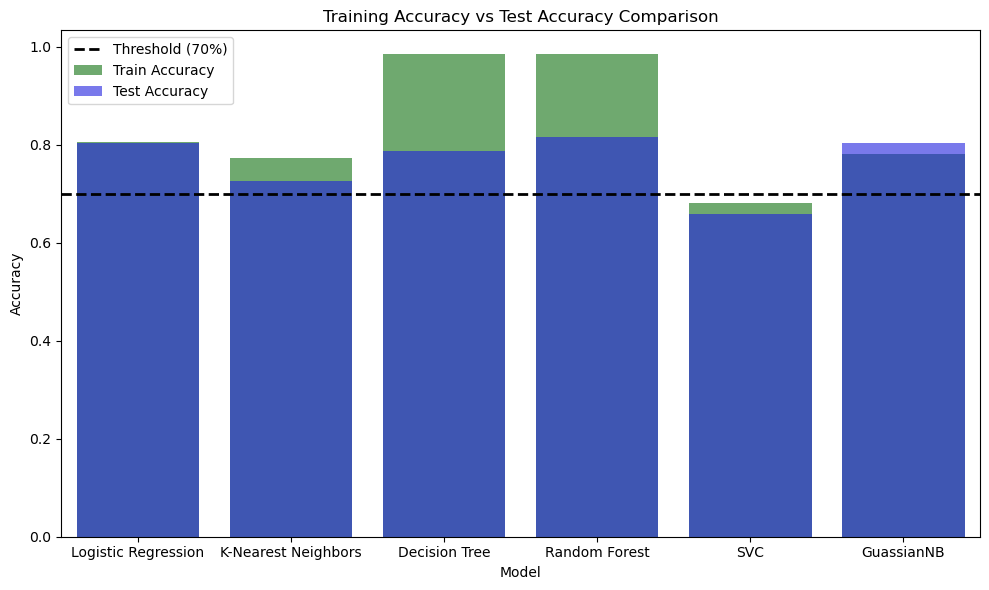

In [99]:
acc_results = pd.DataFrame({
    "Model": ["Logistic Regression", "K-Nearest Neighbors","Decision Tree", "Random Forest", "SVC", "GuassianNB"],
    "Train Accuracy": [lr_train_acc, knn_train_acc, dt_train_acc, rf_train_acc, svc_train_acc, gnb_train_acc],
    "Test Accuracy": [lr_test_acc, knn_test_acc, dt_test_acc, rf_test_acc, svc_test_acc, gnb_test_acc]
})

# Create figure and axis
fig, ax1 = plt.subplots(figsize=(10, 6))


# Plot Accuracy (Train & Test) on left y-axis
ax1.set_title("Training Accuracy vs Test Accuracy Comparison")
ax1.set_xlabel("Model")
sns.barplot(data=acc_results, x="Model", y="Train Accuracy", color = 'green', alpha=0.6, label="Train Accuracy", ax=ax1)
sns.barplot(data=acc_results, x="Model", y="Test Accuracy", color = 'blue', alpha=0.6, label="Test Accuracy", ax=ax1)
ax1.tick_params(axis="y")
ax1.set_ylabel("Accuracy")

# Add threshold line for accuracy at 70%
ax1.axhline(y=0.7, color="black", linestyle="--", linewidth=2, label="Threshold (70%)")

# Legends
ax1.legend(loc="upper left")
plt.tight_layout()
plt.savefig("Images/Titanic/Model_Performance_Comparison.png")
plt.show()

In [100]:
acc_results

,Model,Train Accuracy,Test Accuracy
0,Logistic Regression,0.806180,0.804469
1,K-Nearest Neighbors,0.773876,0.726257
2,Decision Tree,0.984551,0.787709
3,Random Forest,0.984551,0.815642
4,SVC,0.681180,0.659218
5,GuassianNB,0.780899,0.804469


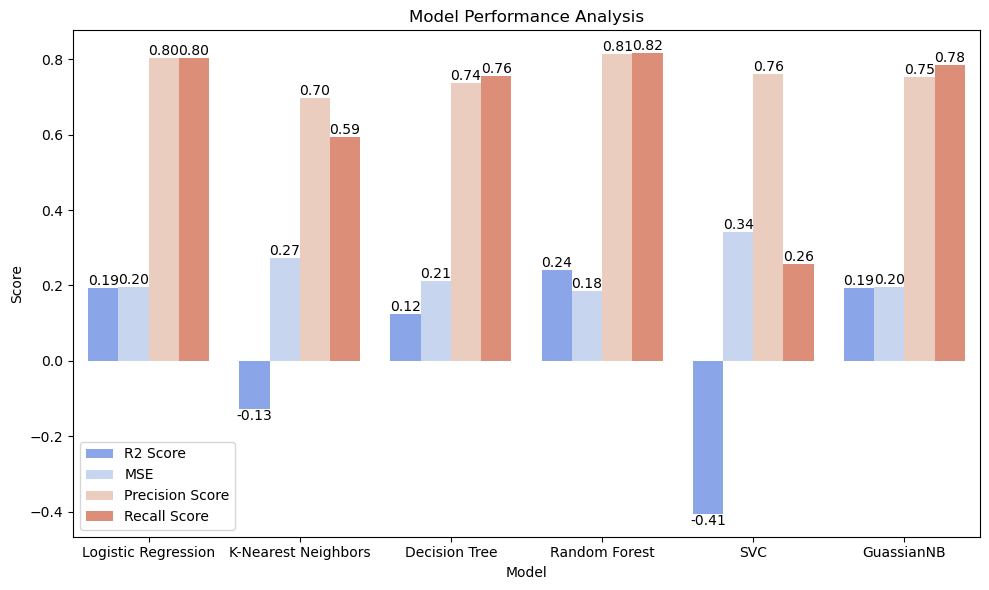

In [101]:
mod_analysis = pd.DataFrame({
    "Model": ["Logistic Regression", "K-Nearest Neighbors","Decision Tree", "Random Forest", "SVC", "GuassianNB"],
    "R2 Score": [lr_r2, knn_r2, dt_r2, rf_r2, svc_r2, gnb_r2],
    "MSE": [lr_mse, knn_mse, dt_mse, rf_mse, svc_mse, gnb_mse],
    "Precision Score": [lr_precision, knn_precision, dt_precision, rf_precision, svc_precision, gnb_precision],
    "Recall Score": [lr_recall, knn_recall, dt_recall, rf_recall, svc_recall, gnb_recall]
})

# Melt the data together for easier visualization
modal_melted = mod_analysis.melt(id_vars="Model", var_name="Metric", value_name="Score")

# Create figure and axis
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot Accuracy (Train & Test) on left y-axis
ax1.set_title("Model Performance Analysis")
ax1.set_xlabel("Model")
ax1.set_ylabel("Score")
ax1.tick_params(axis="y")
perfal1 = sns.barplot(data=modal_melted, x="Model", y="Score", hue="Metric", palette="coolwarm")

for container in perfal1.containers:
    perfal1.bar_label(container, fmt='%.2f')

# Legends
ax1.legend(loc="lower left")
plt.tight_layout()
plt.savefig("Images/Titanic/Model_Performance_Analysis.png")
plt.show()

In [102]:
mod_analysis

,Model,R2 Score,MSE,Precision Score,Recall Score
0,Logistic Regression,0.193694,0.195531,0.803641,0.804469
1,K-Nearest Neighbors,-0.128829,0.273743,0.698413,0.594595
2,Decision Tree,0.124582,0.212291,0.736842,0.756757
3,Random Forest,0.239768,0.184358,0.814800,0.815642
4,SVC,-0.405277,0.340782,0.760000,0.256757
5,GuassianNB,0.193694,0.195531,0.753247,0.783784


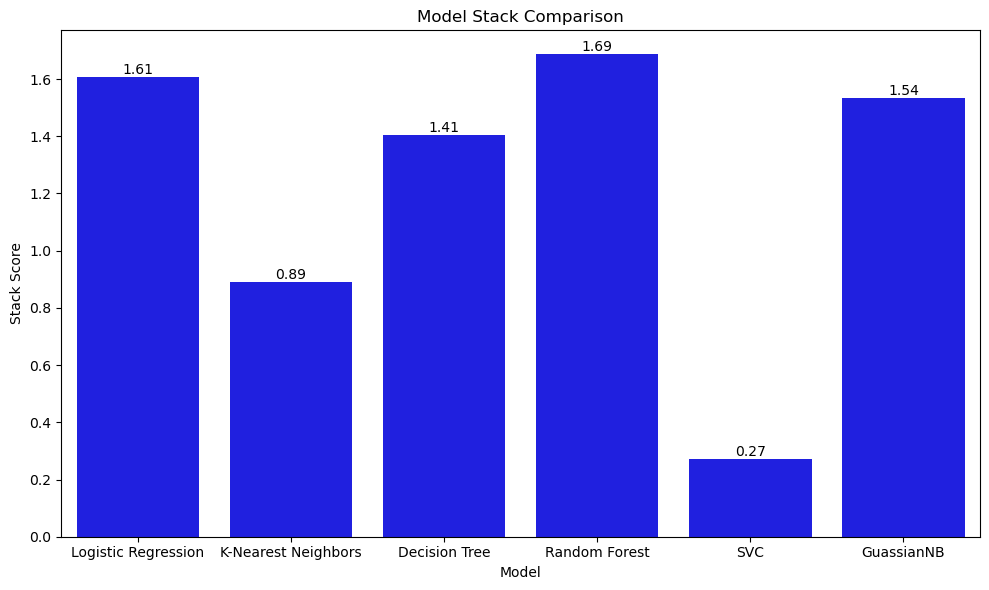

In [103]:
lr_stack = lr_r2+lr_precision+lr_recall-lr_mse
knn_stack = knn_r2+knn_precision+knn_recall-knn_mse
rf_stack = rf_r2+rf_precision+rf_recall-rf_mse
dt_stack = dt_r2+dt_precision+dt_recall-dt_mse
svc_stack = svc_r2+svc_precision+svc_recall-svc_mse
gnb_stack = gnb_r2+gnb_precision+gnb_recall-gnb_mse

mod_stack1 = pd.DataFrame({
    "Model": ["Logistic Regression", "K-Nearest Neighbors","Decision Tree", "Random Forest", "SVC", "GuassianNB"],
    "Stack Score": [lr_stack, knn_stack, dt_stack, rf_stack, svc_stack, gnb_stack]
})

fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot Accuracy (Train & Test) on left y-axis
ax1.set_title("Model Stack Comparison")
ax1.set_xlabel("Model")
ax1.set_ylabel("Score")
ax1.tick_params(axis="y")
perfal1 = sns.barplot(data=mod_stack1, x="Model", y="Stack Score", color = 'blue')

for container in perfal1.containers:
    perfal1.bar_label(container, fmt='%.2f')

# Legends
#ax1.legend(loc="lower left")
plt.tight_layout()
plt.savefig("Images/Titanic/Model_Stack_Comparison.png")
plt.show()

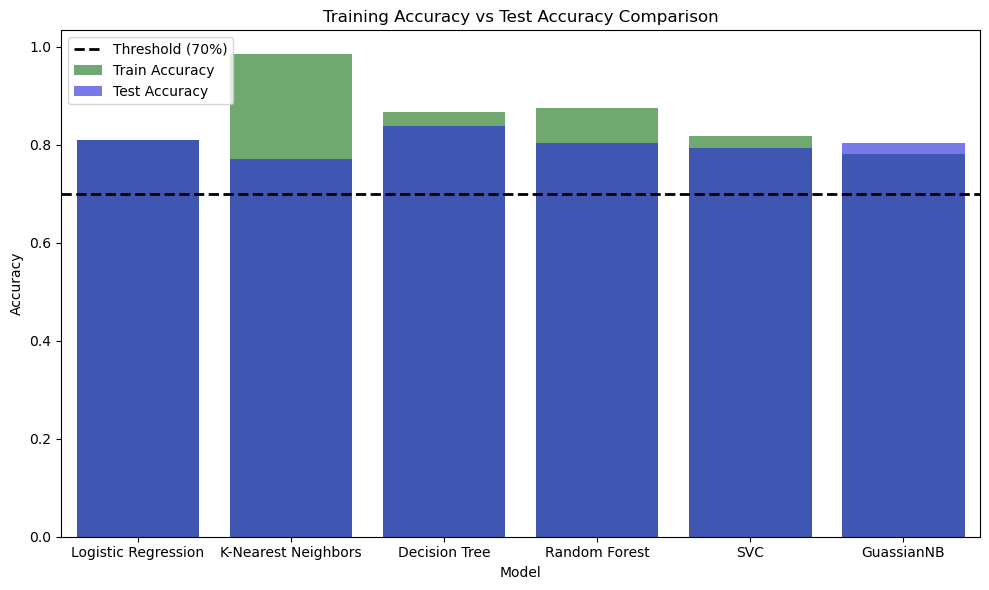

In [104]:
acc_results2 = pd.DataFrame({
    "Model": ["Logistic Regression", "K-Nearest Neighbors","Decision Tree", "Random Forest", "SVC", "GuassianNB"],
    "Train Accuracy": [lr2_train_acc, knn2_train_acc, dt2_train_acc, rf2_train_acc, svc2_train_acc, gnb2_train_acc],
    "Test Accuracy": [lr2_test_acc, knn2_test_acc, dt2_test_acc, rf2_test_acc, svc2_test_acc, gnb2_test_acc]
})

# Create figure and axis
fig, ax1 = plt.subplots(figsize=(10, 6))


# Plot Accuracy (Train & Test) on left y-axis
ax1.set_title("Training Accuracy vs Test Accuracy Comparison")
ax1.set_xlabel("Model")
sns.barplot(data=acc_results2, x="Model", y="Train Accuracy", color = 'green', alpha=0.6, label="Train Accuracy", ax=ax1)
sns.barplot(data=acc_results2, x="Model", y="Test Accuracy", color = 'blue', alpha=0.6, label="Test Accuracy", ax=ax1)
ax1.tick_params(axis="y")
ax1.set_ylabel("Accuracy")

# Add threshold line for accuracy at 70%
ax1.axhline(y=0.7, color="black", linestyle="--", linewidth=2, label="Threshold (70%)")

# Legends
ax1.legend(loc="upper left")
plt.tight_layout()
plt.savefig("Images/Titanic/GSCV_Performance_Comparison.png")
plt.show()

In [105]:
acc_results2

,Model,Train Accuracy,Test Accuracy
0,Logistic Regression,0.808989,0.810056
1,K-Nearest Neighbors,0.984551,0.770950
2,Decision Tree,0.867978,0.837989
3,Random Forest,0.875000,0.804469
4,SVC,0.817416,0.793296
5,GuassianNB,0.780899,0.804469


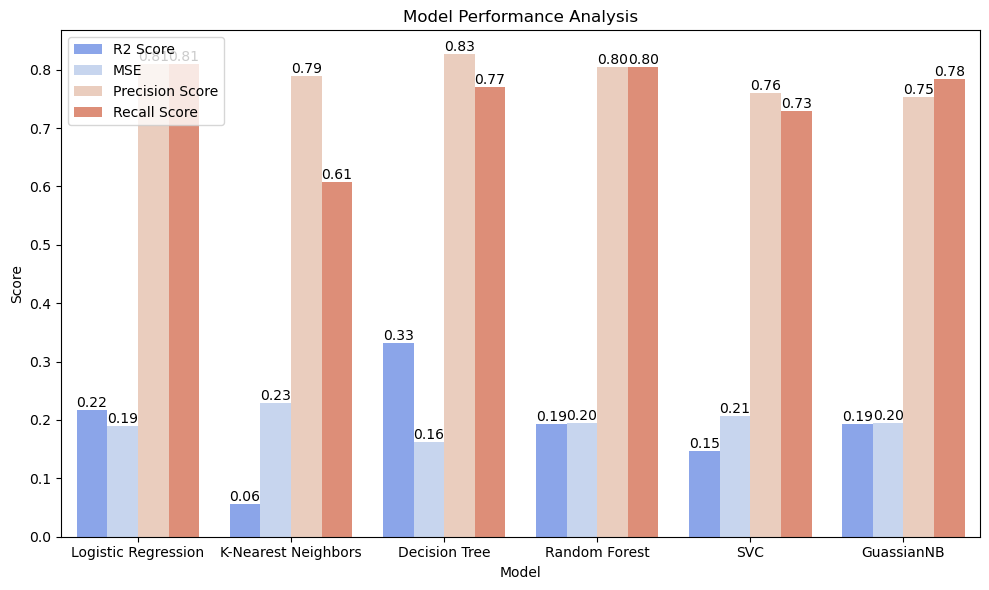

In [106]:
mod_analysis2 = pd.DataFrame({
    "Model": ["Logistic Regression", "K-Nearest Neighbors","Decision Tree", "Random Forest", "SVC", "GuassianNB"],
    "R2 Score": [lr2_r2, knn2_r2, dt2_r2, rf2_r2, svc2_r2, gnb2_r2],
    "MSE": [lr2_mse, knn2_mse, dt2_mse, rf2_mse, svc2_mse, gnb2_mse],
    "Precision Score": [lr2_precision, knn2_precision, dt2_precision, rf2_precision, svc2_precision, gnb2_precision],
    "Recall Score": [lr2_recall, knn2_recall, dt2_recall, rf2_recall, svc2_recall, gnb2_recall]
})

# Melt the data together for easier visualization
modal_melted2 = mod_analysis2.melt(id_vars="Model", var_name="Metric", value_name="Score")

# Create figure and axis
fig, ax2 = plt.subplots(figsize=(10, 6))

# Plot Accuracy (Train & Test) on left y-axis
ax2.set_title("Model Performance Analysis")
ax2.set_xlabel("Model")
ax2.set_ylabel("Score")
ax2.tick_params(axis="y")
perfal2 = sns.barplot(data=modal_melted2, x="Model", y="Score", hue="Metric", palette="coolwarm")

for container in perfal2.containers:
    perfal2.bar_label(container, fmt='%.2f')

# Legends
ax2.legend(loc="upper left")
plt.tight_layout()
plt.savefig("Images/Titanic/Model_Performance2_Analysis.png")
plt.show()

In [107]:
mod_analysis2

,Model,R2 Score,MSE,Precision Score,Recall Score
0,Logistic Regression,0.216731,0.189944,0.809163,0.810056
1,K-Nearest Neighbors,0.055470,0.229050,0.789474,0.608108
2,Decision Tree,0.331918,0.162011,0.826087,0.770270
3,Random Forest,0.193694,0.195531,0.804949,0.804469
4,SVC,0.147619,0.206704,0.760563,0.729730
5,GuassianNB,0.193694,0.195531,0.753247,0.783784


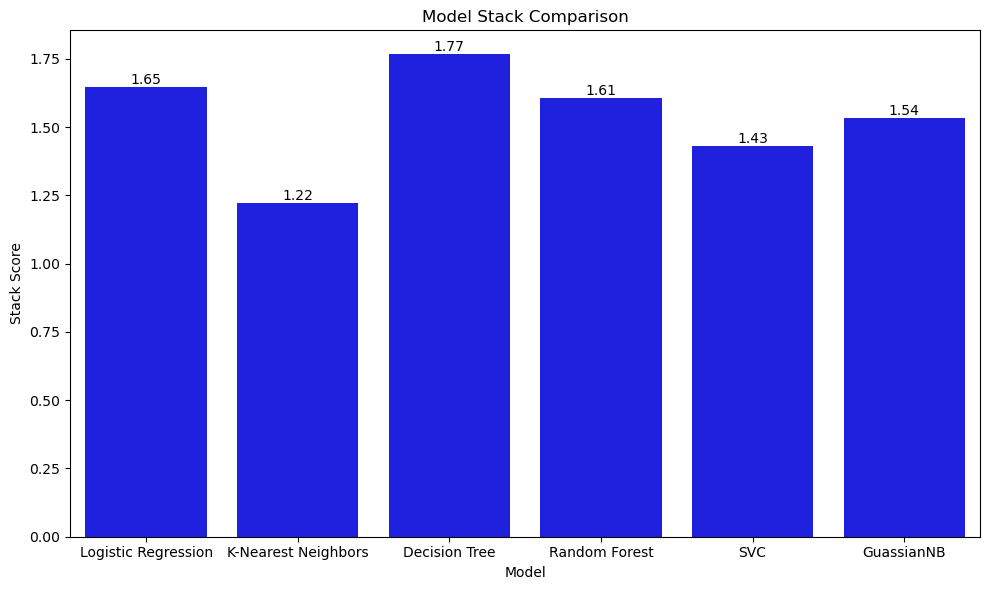

In [108]:
lr_stack2 = lr2_r2+lr2_precision+lr2_recall-lr2_mse
knn_stack2 = knn2_r2+knn2_precision+knn2_recall-knn2_mse
rf_stack2 = rf2_r2+rf2_precision+rf2_recall-rf2_mse
dt_stack2 = dt2_r2+dt2_precision+dt2_recall-dt2_mse
svc_stack2 = svc2_r2+svc2_precision+svc2_recall-svc2_mse
gnb_stack2 = gnb2_r2+gnb2_precision+gnb2_recall-gnb2_mse

mod_stack1 = pd.DataFrame({
    "Model": ["Logistic Regression", "K-Nearest Neighbors","Decision Tree", "Random Forest", "SVC", "GuassianNB"],
    "Stack Score": [lr_stack2, knn_stack2, dt_stack2, rf_stack2, svc_stack2, gnb_stack2]
})

fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot Accuracy (Train & Test) on left y-axis
ax1.set_title("Model Stack Comparison")
ax1.set_xlabel("Model")
ax1.set_ylabel("Score")
ax1.tick_params(axis="y")
perfal1 = sns.barplot(data=mod_stack1, x="Model", y="Stack Score", color = 'blue')

for container in perfal1.containers:
    perfal1.bar_label(container, fmt='%.2f')

# Legends
#ax1.legend(loc="lower left")
plt.tight_layout()
plt.savefig("Images/Titanic/Model_Stack_Comparison2.png")
plt.show()

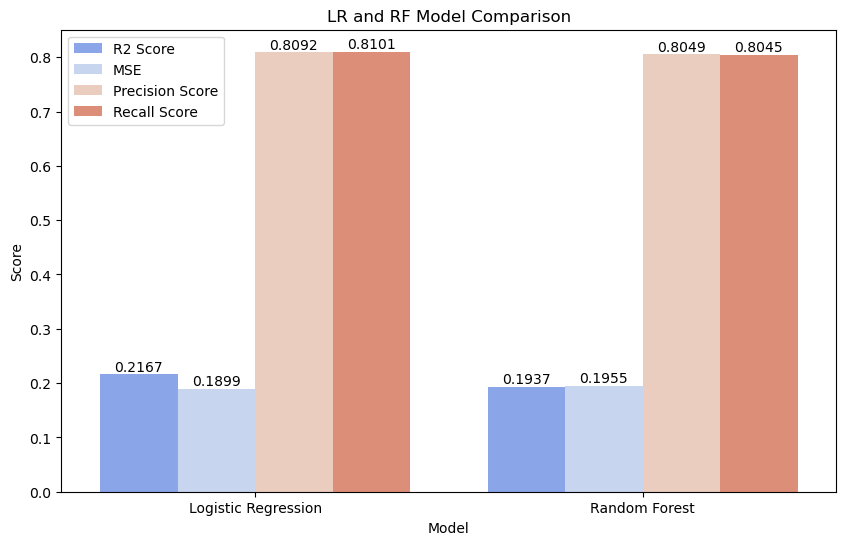

In [109]:
comp_analysis = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "R2 Score": [lr2_r2, rf2_r2],
    "MSE": [lr2_mse, rf2_mse],
    "Precision Score": [lr2_precision, rf2_precision],
    "Recall Score": [lr2_recall, rf2_recall]
})

# Melt the data together for easier visualization
comp_melt = comp_analysis.melt(id_vars="Model", var_name="Metric", value_name="Score")

# Create figure and axis
fig, ax2 = plt.subplots(figsize=(10, 6))

# Plot Accuracy (Train & Test) on left y-axis
ax2.set_title("LR and RF Model Comparison")
ax2.set_xlabel("Model")
ax2.set_ylabel("Score")
ax2.tick_params(axis="y")
comp1 = sns.barplot(data=comp_melt, x="Model", y="Score", hue="Metric", palette="coolwarm")

for container in comp1.containers:
    comp1.bar_label(container, fmt='%.4f')
# Legends
ax2.legend(loc="upper left")

#plt01.tight_layout()
plt.savefig("Images/Titanic/LR_vs_RF_comparison.png")
plt.show()

In [110]:
d3.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Cabin_Cat,Famsi,Age_Group,Fare_Group,Famsi_Grouped,Ticket_Number
0,892,3,"Kelly, Mr. James",0,34.5,0,0,330911,7.8292,U,2,0,1,30.0,0.0,Alone,330911
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",1,47.0,1,0,363272,7.0000,U,0,0,2,40.0,0.0,Small,363272
2,894,2,"Myles, Mr. Thomas Francis",0,62.0,0,0,240276,9.6875,U,2,0,1,60.0,0.0,Alone,240276
3,895,3,"Wirz, Mr. Albert",0,27.0,0,0,315154,8.6625,U,0,0,1,20.0,0.0,Alone,315154
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",1,22.0,1,1,3101298,12.2875,U,0,0,3,20.0,0.0,Small,3101298


In [111]:
d3t = d3.drop(columns =['Name','Ticket','Cabin','Famsi_Grouped','Ticket_Number','PassengerId'], axis = 1)
d3t.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Cabin_Cat,Famsi,Age_Group,Fare_Group
0,3,0,34.5,0,0,7.8292,2,0,1,30.0,0.0
1,3,1,47.0,1,0,7.0000,0,0,2,40.0,0.0
2,2,0,62.0,0,0,9.6875,2,0,1,60.0,0.0
3,3,0,27.0,0,0,8.6625,0,0,1,20.0,0.0
4,3,1,22.0,1,1,12.2875,0,0,3,20.0,0.0


In [112]:
d3.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Cabin_Cat,Famsi,Age_Group,Fare_Group,Famsi_Grouped,Ticket_Number
0,892,3,"Kelly, Mr. James",0,34.5,0,0,330911,7.8292,U,2,0,1,30.0,0.0,Alone,330911
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",1,47.0,1,0,363272,7.0000,U,0,0,2,40.0,0.0,Small,363272
2,894,2,"Myles, Mr. Thomas Francis",0,62.0,0,0,240276,9.6875,U,2,0,1,60.0,0.0,Alone,240276
3,895,3,"Wirz, Mr. Albert",0,27.0,0,0,315154,8.6625,U,0,0,1,20.0,0.0,Alone,315154
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",1,22.0,1,1,3101298,12.2875,U,0,0,3,20.0,0.0,Small,3101298


In [113]:
X_test.sample(10)

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Cabin_Cat,Famsi,Age_Group,Fare_Group
375,1,1,29.699118,1,0,82.1708,2,0,2,20.0,75.0
876,3,0,20.000000,0,0,9.8458,1,0,1,20.0,0.0
514,3,0,24.000000,0,0,7.4958,1,0,1,20.0,0.0
360,3,0,40.000000,1,4,27.9000,1,0,6,40.0,25.0
518,2,1,36.000000,1,0,26.0000,1,0,2,30.0,25.0
796,1,1,49.000000,0,0,25.9292,1,1,1,40.0,25.0
165,3,0,9.000000,0,2,20.5250,1,0,3,0.0,0.0
227,3,0,20.500000,0,0,7.2500,1,0,1,20.0,0.0
842,1,1,30.000000,0,0,31.0000,2,0,1,30.0,25.0
773,3,0,29.699118,0,0,7.2250,2,0,1,20.0,0.0


In [114]:
lr_GSCV_pred = lr_GSCV.predict(d3t)
rf_GSCV_pred = rf_GSCV.predict(d3t)
dt_GSCV_pred = dt_GSCV.predict(d3t)
knn_GSCV_pred = knn_GSCV.predict(d3t)
svc_GSCV_pred = svc_GSCV.predict(d3t)
gnb_GSCV_pred = gnb_GSCV.predict(d3t)

In [115]:
d3.sample()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Cabin_Cat,Famsi,Age_Group,Fare_Group,Famsi_Grouped,Ticket_Number
212,1104,2,"Deacon, Mr. Percy William",0,17.0,0,0,S.O.C. 14879,73.5,U,0,0,1,10.0,50.0,Alone,14879


In [116]:
sub1 = pd.DataFrame({
    'PassengerId':d3['PassengerId'],
    'Survived':lr_GSCV_pred,
})

sub2 = pd.DataFrame({
    'PassengerId':d3['PassengerId'],
    'Survived':rf_GSCV_pred,
})

sub3 = pd.DataFrame({
    'PassengerId':d3['PassengerId'],
    'Survived':dt_GSCV_pred,
})

sub4 = pd.DataFrame({
    'PassengerId':d3['PassengerId'],
    'Survived':knn_GSCV_pred,
})

sub5 = pd.DataFrame({
    'PassengerId':d3['PassengerId'],
    'Survived':svc_GSCV_pred,
})

sub6 = pd.DataFrame({
    'PassengerId':d3['PassengerId'],
    'Survived':gnb_GSCV_pred,
})

In [117]:
sub1.to_csv('Titanic/sub1.csv',index = False)
sub2.to_csv('Titanic/sub2.csv',index = False)
sub3.to_csv('Titanic/sub3.csv',index = False)
sub4.to_csv('Titanic/sub4.csv',index = False)
sub5.to_csv('Titanic/sub5.csv',index = False)
sub6.to_csv('Titanic/sub6.csv',index = False)

In [118]:
sub1.sample(15)

,PassengerId,Survived
12,904,1
27,919,0
78,970,0
74,966,1
38,930,0
376,1268,0
91,983,0
51,943,0
108,1000,0
241,1133,0


In [119]:
d2['Fare'].mean()

32.204207968574636

In [120]:
X_test.sample(1)

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Cabin_Cat,Famsi,Age_Group,Fare_Group
165,3,0,9.0,0,2,20.525,1,0,3,0.0,0.0


In [121]:
input_data = (1,0,28,1,2,32.5,1,1,4,20,25)

input_data_asarray = np.asarray(input_data)
input_data_reshaped = input_data_asarray.reshape(1,-1)

In [122]:
lr_prediction1 = lr.predict(input_data_reshaped)
rf_prediction1 = rf.predict(input_data_reshaped)
dt_prediction1 = dt.predict(input_data_reshaped)
knn_prediction1 = knn.predict(input_data_reshaped)
svc_prediction1 = svc.predict(input_data_reshaped)
gnb_prediction1 = gnb.predict(input_data_reshaped)
print(lr_prediction1[0], rf_prediction1[0], dt_prediction1[0], knn_prediction1[0], svc_prediction1[0], gnb_prediction1[0])

0 0 0 1 0 1


C:\Users\marcu\anaconda3\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
C:\Users\marcu\anaconda3\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\marcu\anaconda3\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\marcu\anaconda3\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
C:\Users\marcu\anaconda3\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
C:\Users\marcu\anaco

In [123]:
lr_prediction2 = lr2.predict(input_data_reshaped)
rf_prediction2 = rf2.predict(input_data_reshaped)
dt_prediction2 = dt2.predict(input_data_reshaped)
knn_prediction2 = knn2.predict(input_data_reshaped)
svc_prediction2 = svc2.predict(input_data_reshaped)
gnb_prediction2 = gnb2.predict(input_data_reshaped)
print(lr_prediction2[0], rf_prediction2[0], dt_prediction2[0], knn_prediction2[0], svc_prediction2[0], gnb_prediction2[0])

0 0 1 1 0 1


C:\Users\marcu\anaconda3\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
C:\Users\marcu\anaconda3\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\marcu\anaconda3\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\marcu\anaconda3\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
C:\Users\marcu\anaconda3\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
C:\Users\marcu\anaco